In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Testar a leitura do ficheiro
df = pd.read_csv("Tabela4.csv", sep=";", decimal=",", header=1, encoding="latin1")
print("Bibliotecas carregadas com sucesso!")
print(df.head())

Bibliotecas carregadas com sucesso!
  Sigla  Código    Estado   1991   2000   2010   2012   2013   2014   2015  \
0    AC      12      Acre  0.402  0.517  0.663  0.705  0.709  0.719  0.719   
1    AL      27   Alagoas  0.370  0.471  0.631  0.657  0.653  0.670  0.669   
2    AM      13  Amazonas  0.430  0.515  0.674  0.706  0.717  0.720  0.724   
3    AP      16     Amapá  0.472  0.577  0.708  0.709  0.735  0.726  0.728   
4    BA      29     Bahia  0.386  0.512  0.660  0.684  0.686  0.700  0.708   

    2016   2017   2018   2019   2020   2021   2022   2023   2024  
0  0.723  0.711  0.731  0.738  0.736  0.702  0.732  0.740  0.754  
1  0.680  0.682  0.694  0.693  0.694  0.691  0.722  0.739  0.746  
2  0.723  0.743  0.732  0.739  0.725  0.700  0.757  0.764  0.767  
3  0.732  0.731  0.737  0.732  0.707  0.681  0.743  0.767  0.759  
4  0.708  0.715  0.714  0.723  0.726  0.698  0.734  0.740  0.759  


--- Top 5 estados com maior IDH em 2024 ---
   Sigla            Estado   2024
6     DF  Distrito Federal  0.866
25    SP         São Paulo  0.838
23    SC    Santa Catarina  0.833
17    PR            Paraná  0.822
18    RJ    Rio de Janeiro  0.819

Maior melhora: Tocantins (TO) com ganho de +0.428
Nenhum estado piorou seu IDH entre 1991 e 2024.


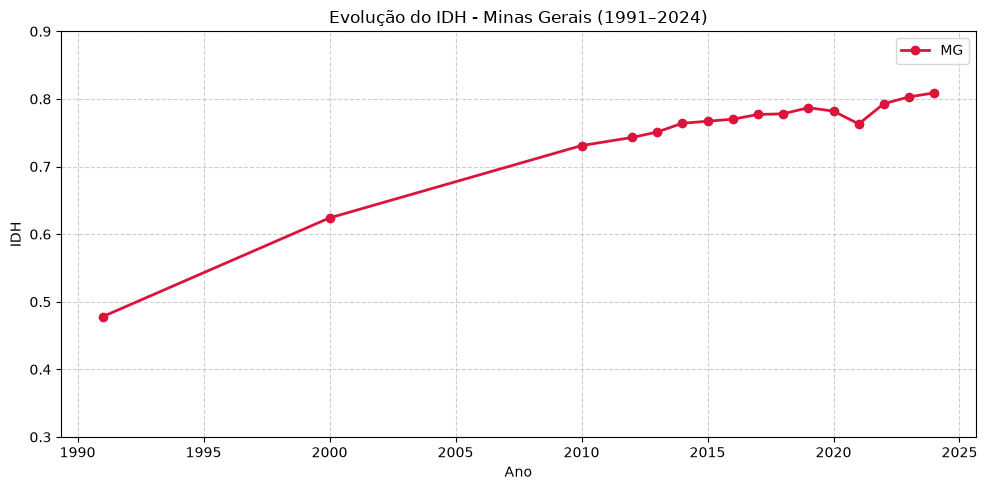

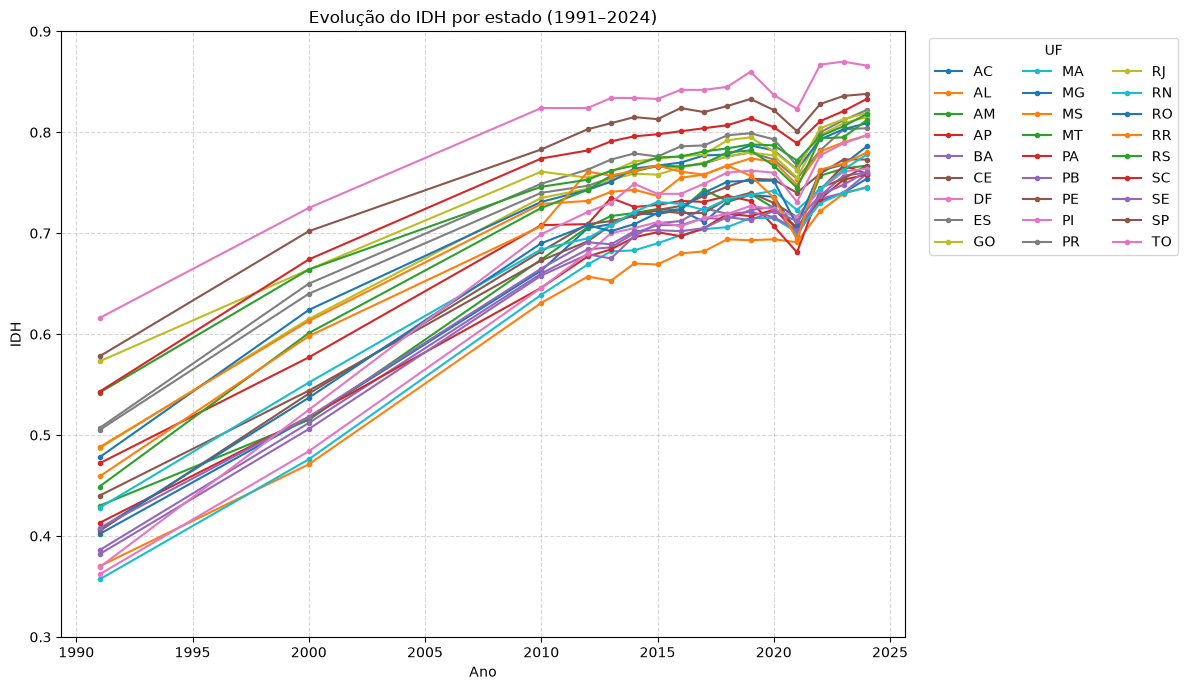

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Carregar os dados
df = pd.read_csv("Tabela4.csv", sep=";", decimal=",", header=1, encoding="latin1")

# 2. Limpar linhas e colunas nulas (se houver)
df = df.dropna(how="all", axis=1).dropna(how="all", axis=0)

# 3. Ordene os estados por maior IDH em 2024
df_2024 = df.sort_values(by="2024", ascending=False)
print("--- Top 5 estados com maior IDH em 2024 ---")
print(df_2024[["Sigla", "Estado", "2024"]].head())

# 4. Qual estado teve a maior melhora de IDH entre 2024 e 1991?
df["Evolucao_1991_2024"] = df["2024"] - df["1991"]
maior_melhora = df.loc[df["Evolucao_1991_2024"].idxmax()]
print(
    f"\nMaior melhora: {maior_melhora['Estado']} ({maior_melhora['Sigla']}) "
    f"com ganho de +{maior_melhora['Evolucao_1991_2024']:.3f}"
)

# 5. Existe algum estado em que o IDH piorou?
pioraram = df[df["Evolucao_1991_2024"] < 0]
if pioraram.empty:
    print("Nenhum estado piorou seu IDH entre 1991 e 2024.")

# 6. Passar a tabela para o formato longo (melt)
anos = [c for c in df.columns if str(c).isdigit()]
id_vars = [c for c in df.columns if c not in anos and c != "Evolucao_1991_2024"]

df_longo = df.melt(
    id_vars=id_vars, value_vars=anos, var_name="Ano", value_name="IDH"
)

df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")

# 7. Plote apenas Minas Gerais
df_mg = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    df_mg["Ano"],
    df_mg["IDH"],
    marker="o",
    color="crimson",
    linewidth=2,
    label="MG",
)
ax.set_title("Evolução do IDH - Minas Gerais (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
fig.tight_layout()
plt.show()

# 8. Plotar a evolução do IDH de todos os estados
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(
        grupo["Ano"],
        grupo["IDH"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=sigla,
    )

ax.set_title("Evolução do IDH por estado (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
plt.show()